In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
df = pd.read_csv('/content/drive/MyDrive/DataScienceProjects/MusicGenrePredictor/dataset.csv',index_col=0)
## filters the dataset to a small number of distinct genres, as the orignal dataset contains 125 unique genres
selected_genres = ['classical', 'hip-hop', 'metal', 'jazz', 'pop', 'acoustic', 'edm', 'country']
df = df[df['track_genre'].isin(selected_genres)]
df.head()

,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,1,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,1,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,0,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,0,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,2,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


In [3]:
##### DATA CLEANING #####

## drops rows that are completely identical
print(f'There are {df.duplicated().sum()} duplicate rows')
df=df.drop_duplicates()
print(f'After removing duplicates, there are {df.duplicated(subset=['track_id']).sum()} rows with the same track_id but different genre')

## this gives us quite interesting data, as there are more rows with the same track id than identical rows, I want to explore why some songs are in the dataset more than
## once with different audio features

## shows the tracks that have the same track id but different genre
duplicate_track_id=df[df['track_id'].duplicated(keep=False)].sort_values(by='track_id')
print("\n Sample of 3 songs with conflicting genres: \n")
print(duplicate_track_id[['track_name','artists','track_genre']].head(6))
## this shows us that some tracks are featured twice but with different genres, I need to decide how to treat these. I will remove all instances of the song, as to not
## feed the training data the exact same audio features with different genres, which may confuse the model (as clearly the creator of the dataset is unable to decide on it either)
df=df.drop_duplicates(subset=['track_id'], keep=False)

## some columns do not represent audio features, such as album_name, so these will also be removed
columns_to_drop = ['track_id','artists','album_name','track_name','popularity'] ## decided to drop popularity, as although genre effects popularity, I want the model to be based purely on audio features
df = df.drop(columns=['track_id', 'artists', 'album_name', 'track_name', 'popularity'])


There are 93 duplicate rows
After removing duplicates, there are 176 rows with the same track_id but different genre

 Sample of 3 songs with conflicting genres: 

                track_name                  artists track_genre
81361              FRIENDS    Marshmello;Anne-Marie         pop
30009              FRIENDS    Marshmello;Anne-Marie         edm
81966  Dirty Little Secret  Zack Knight;Nora Fatehi         pop
51156  Dirty Little Secret  Zack Knight;Nora Fatehi     hip-hop
81407  Love Me Like You Do           Ellie Goulding         pop
30002  Love Me Like You Do           Ellie Goulding         edm


<Axes: xlabel='loudness', ylabel='valence'>

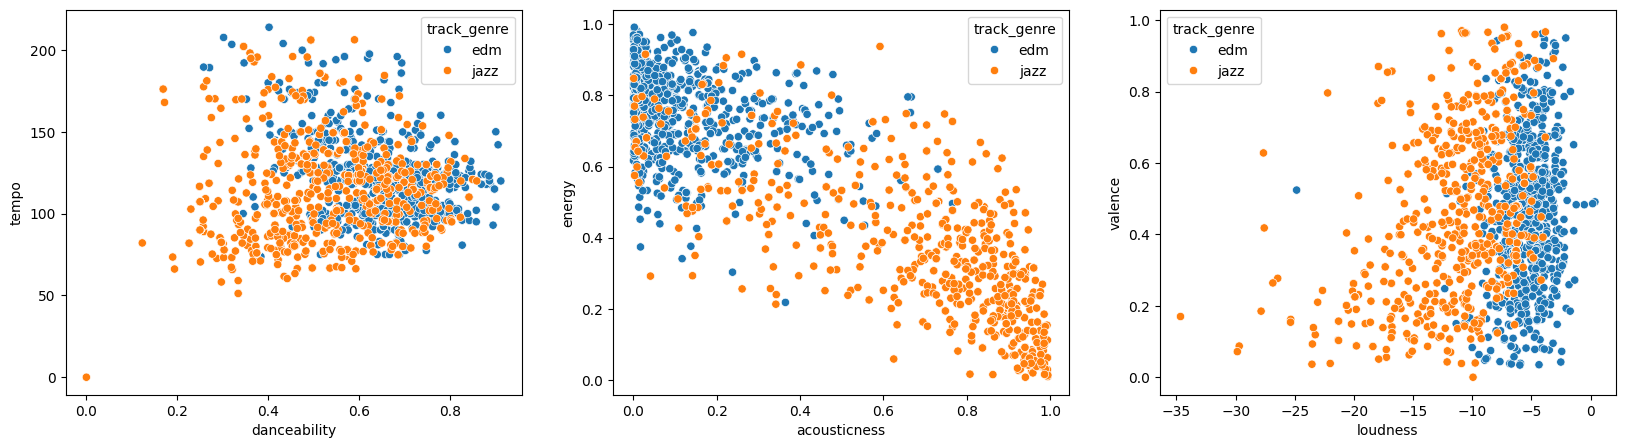

In [4]:
##### EXPLORATORY DATA ANALYSIS #####

import seaborn as sns
import matplotlib.pyplot as plt

## some features distinguish between genress better than others, as you can see, edm and jazz have a tempo and danceability, but their energy and accousticness are more distinct from each other
## Lets explore how different features of a song vary between all genres, and which are more significant in determinng a song's genre
jazz_vs_edm = df[df['track_genre'].isin(['jazz','edm'])]

fig, axes = plt.subplots(1,3, figsize=(20,5))

sns.scatterplot(
    data=jazz_vs_edm,
    x='danceability',
    y='tempo',
    hue='track_genre',
    ax=axes[0]
)
sns.scatterplot(
    data=jazz_vs_edm,
    x='acousticness',
    y='energy',
    hue='track_genre',
    ax=axes[1]
)
sns.scatterplot(
    data=jazz_vs_edm,
    x='loudness',
    y='valence',
    hue='track_genre',
    ax=axes[2]
)

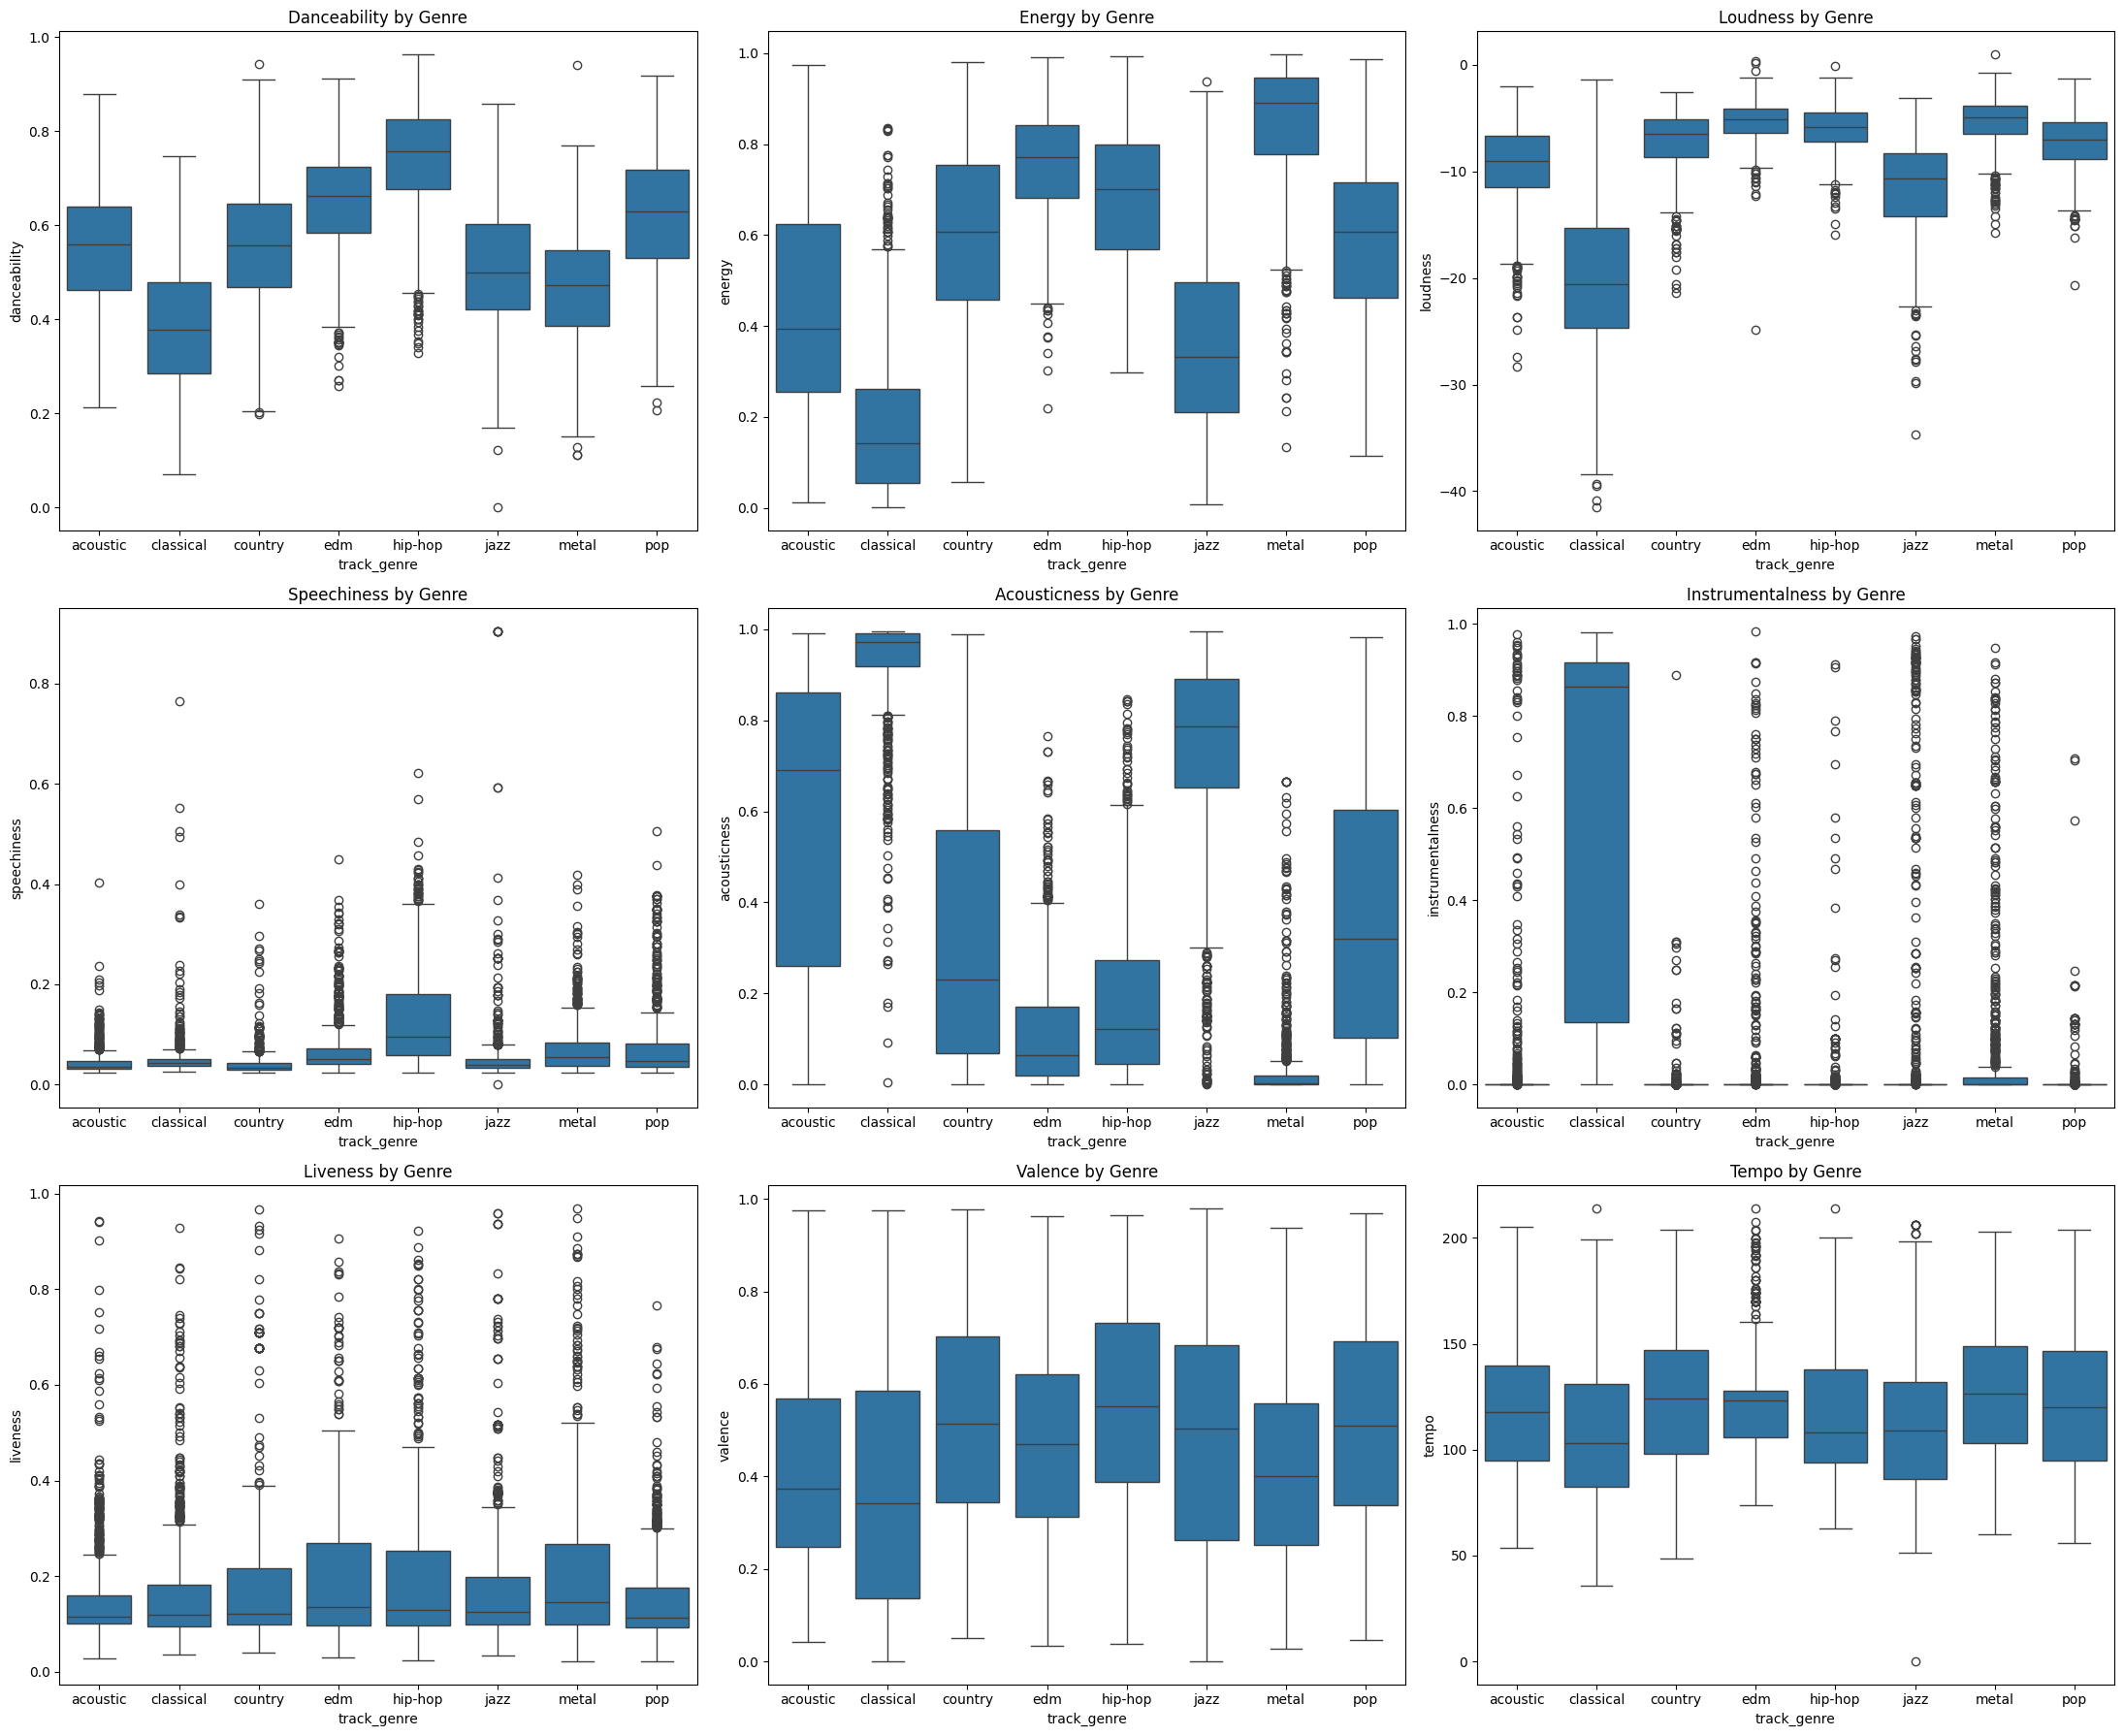

In [5]:
##### EXPLORATORY DATA ANALYSIS #####

fig, axes = plt.subplots(3,3, figsize=(22,18))
features = ['danceability', 'energy', 'loudness', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo']
for index in range(0,9):
    sns.boxplot(
        data=df,
        x='track_genre',
        y=features[index],
        ax = axes[index // 3, index % 3]
    )
    axes[index // 3, index % 3].set_title(f'{features[index].capitalize()} by Genre')

plt.tight_layout()
## as you can see, some values of musical features are more indicative of genres than others. As you can see, liveness, valence, and tempo all appear to be similar ragrdless of genre. On the other hand,
## an instrumentallness of of above 0.2 appears to strongly indicate the music is classical, a speechinesss of above 0.04 strongly indicates hip-hop, and an acousticness of 0 would indicate metal.
## These patterns can be used by our model to help predict the genre just by the audio features.


In [6]:
###### PREPARE DATA FOR MODELLING ####

from sklearn.model_selection import train_test_split

y=df.track_genre
X=df.drop(['track_genre'], axis=1)
X_train, X_valid, y_train, y_valid = train_test_split(X, y, train_size=0.8, test_size=0.2, random_state=0)

## converts the explicit column from boolean values to integers so model can read values
X_train_explicit_fix = pd.DataFrame(X_train.explicit.astype(int))
X_valid_explicit_fix = pd.DataFrame(X_valid.explicit.astype(int))

## this combines the categorical data with the numerical data again
X_train = pd.concat([X_train_explicit_fix, X_train.drop(['explicit'],axis=1)],axis=1)
X_valid = pd.concat([X_valid_explicit_fix, X_valid.drop(['explicit'],axis=1)],axis=1)


In [7]:
###### CREATE THE MODEL #######

## this is the first simple model
from sklearn.tree import DecisionTreeClassifier
music_model=DecisionTreeClassifier(random_state=0)
music_model.fit(X_train, y_train)

predictions=music_model.predict(X_valid)

from sklearn.metrics import accuracy_score
predictions = music_model.predict(X_valid)
print(accuracy_score(y_valid, predictions))

from sklearn.metrics import classification_report
print(classification_report(y_valid, predictions))

## as we can see, the genre easiest to predict is classical. This makes sense as when
## viewing the distribution of features over each genre, classical was significantly
## different in its distribution in energy, loudness, acousticness, and instrumentalness.
## The errors in classical music therefore must have come by fairly anomalous results.(MAYBE
## CHECK THIS SOMEHOW)
## The hardest to predict genres are pop and acoustic, perhaps this tells us that these genres
## have a greater variety of sound, and are therefore harder to pinpoint

0.6362433862433863
              precision    recall  f1-score   support

    acoustic       0.47      0.44      0.45       204
   classical       0.79      0.82      0.81       176
     country       0.63      0.65      0.64       206
         edm       0.65      0.68      0.67       190
     hip-hop       0.63      0.58      0.61       188
        jazz       0.68      0.75      0.71       192
       metal       0.75      0.74      0.74       178
         pop       0.48      0.45      0.46       178

    accuracy                           0.64      1512
   macro avg       0.64      0.64      0.64      1512
weighted avg       0.63      0.64      0.63      1512

